# Dog vs Cat Classification using Transfer Learning

In [13]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [14]:
# Organize images into subfolders
train_dir = './train'
for category in ['cats', 'dogs']:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)

for filename in os.listdir(train_dir):
    if filename.startswith('cat.'):
        shutil.move(os.path.join(train_dir, filename), os.path.join(train_dir, 'cats', filename))
    elif filename.startswith('dog.'):
        shutil.move(os.path.join(train_dir, filename), os.path.join(train_dir, 'dogs', filename))

print('Cats:', len(os.listdir(os.path.join(train_dir, 'cats'))))
print('Dogs:', len(os.listdir(os.path.join(train_dir, 'dogs'))))

Cats: 12500
Dogs: 12500


In [15]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

# Training set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation set (no augmentation, just rescale)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


##  Load Pre-trained Model & Build Custom Head

In [16]:
from  keras.applications import VGG16

In [22]:
# Use VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# weights='imagenet' — loads weights pre-trained on 1.4 million images
# include_top=False — removes the original classification head (we'll add our own)
# input_shape=(224, 224, 3) — matches our image size (224×224 RGB)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [23]:
# Freeze the pre-trained layers

for layer in base_model.layers:
    layer.trainable = False

In [27]:
model = keras.Sequential([
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

## Compile & Train the Model

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
history = model.fit(train_generator, validation_data=validation_generator, epochs=5)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1363s 2s/step - accuracy: 0.8805 - loss: 0.3196 - val_accuracy: 0.9162 - val_loss: 0.2114
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1376s 2s/step - accuracy: 0.9146 - loss: 0.2045 - val_accuracy: 0.9150 - val_loss: 0.2032
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1357s 2s/step - accuracy: 0.9212 - loss: 0.1867 - val_accuracy: 0.9162 - val_loss: 0.2016
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1330s 2s/step - accuracy: 0.9223 - loss: 0.1833 - val_accuracy: 0.9076 - val_loss: 0.2158
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1275s 2s/step - accuracy: 0.9311 - loss: 0.1669 - val_accuracy: 0.9196 - val_loss: 0.1937


## Evaluate & Visualize Results

In [30]:
score, acc = model.evaluate(validation_generator)
print('Test Loss =', score)
print('Test Accuracy =', acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9142 - loss: 0.1975
Test Loss = 0.19749633967876434
Test Accuracy = 0.9142000079154968


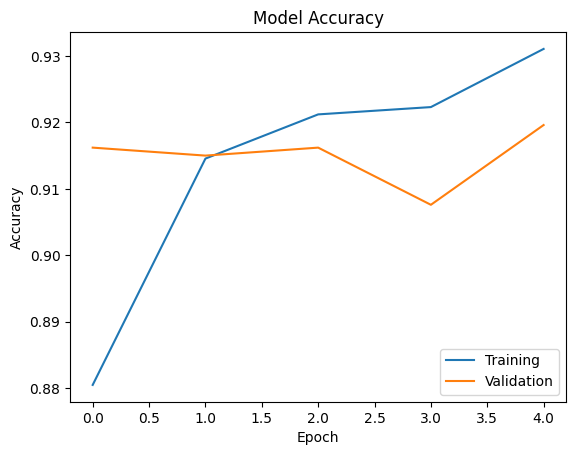

In [39]:
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

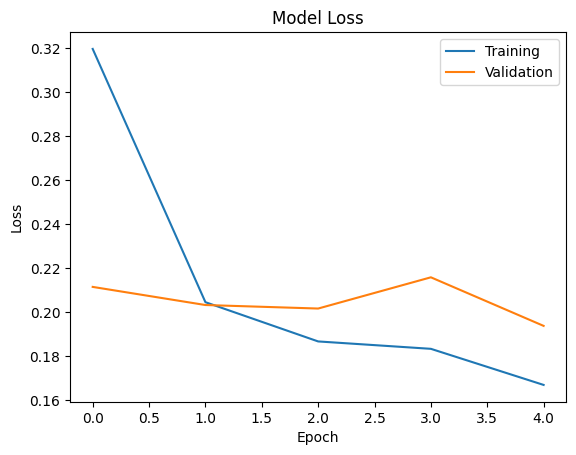

In [40]:
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

##  Build a Prediction System (single image)

{'cats': 0, 'dogs': 1}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Prediction: Cat
Confidence: 0.06937732


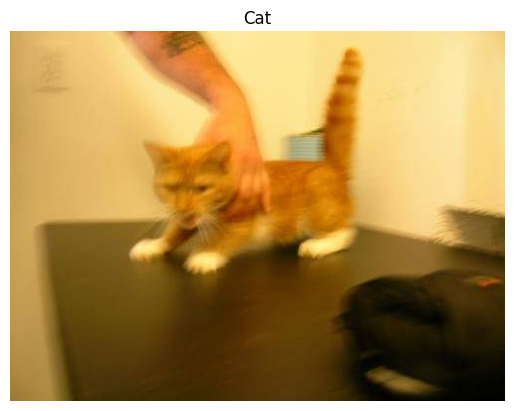

In [41]:
# Check class mapping
print(train_generator.class_indices)

# Load and preprocess a single image
img_path = './train/cats/cat.0.jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
img_array = keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Interpret result
if prediction[0][0] > 0.5:
    label = 'Dog'
else:
    label = 'Cat'

print('Prediction:', label)
print('Confidence:', prediction[0][0])

# Display the image
plt.imshow(keras.utils.load_img(img_path))
plt.title(label)
plt.axis('off')
plt.show()
